# Config & Import

In [1]:
import asyncio, json, time
import httpx
import pandas as pd
import nest_asyncio
nest_asyncio.apply()

CONCURRENCY_LEVELS = [1, 5, 10]
REQUESTS_PER_USER  = 3
MAX_NEW_TOKENS     = 1024
REQUEST_TIMEOUT    = 600

# Config & Import

In [2]:
PROMPTS = [
    "Explain how PagedAttention improves GPU memory utilization in LLM inference servers.",
    "Summarize the key differences between Kubernetes DaemonSet and Deployment workload types.",
    "What are the best practices for securing an air-gapped LLM deployment in an enterprise network?",
    "Compare vLLM and Ollama as inference backends. Focus on throughput, concurrency, and ease of use.",
    "Describe a capacity planning approach for serving a 70B LLM to 200 concurrent enterprise users.",
    "Explain continuous batching and how it differs from static batching for LLM inference.",
    "What monitoring metrics are most critical for a production GPU inference cluster?",
    "How does quantization (INT4/INT8) affect LLM output quality versus inference speed?",
    "Describe the architecture of a RAG pipeline and the role of the retrieval component.",
    "What steps would you take if a containerized vLLM server returns 503 under high load?",
]
print(f"{len(PROMPTS)} prompts ready ✓")

10 prompts ready ✓


# vLLM Config

In [3]:
# ray-multinode-inference
#VLLM_BASE = "http://<RAY_HEAD_NODE_IP>:8000"  # Ray head node 엔드포인트
VLLM_BASE = "http://192.168.1.149:8000"
VLLM_MODEL = "gpt-oss-120b"  # docker logs로 확인 후 입력
print(f"vLLM target: {VLLM_BASE}")

vLLM target: http://192.168.1.149:8000


# vLLM Connectivity Check

In [4]:
async def check_vllm():
    async with httpx.AsyncClient(timeout=10) as client:
        r = await client.get(f"{VLLM_BASE}/health")
        print(f"vLLM health: {r.status_code} ✓")
        r2 = await client.get(f"{VLLM_BASE}/v1/models")
        models = [m['id'] for m in r2.json().get('data', [])]
        print(f"Loaded models: {models}")

asyncio.run(check_vllm())

vLLM health: 200 ✓
Loaded models: ['gpt-oss-120b']


# vLLM Request Function

In [5]:
async def vllm_request(client, user_id, req_id, prompt):
    payload = {
        "model": VLLM_MODEL,
        "messages": [{"role": "user", "content": prompt}],
        "max_tokens": MAX_NEW_TOKENS,
        "stream": True,
        "stream_options": {"include_usage": True},
    }
    t_start = time.perf_counter()
    t_first = None
    tokens  = 0
    error   = None

    try:
        async with client.stream("POST", f"{VLLM_BASE}/v1/chat/completions",
                                 json=payload, timeout=REQUEST_TIMEOUT) as resp:
            resp.raise_for_status()
            async for line in resp.aiter_lines():
                if not line.startswith("data:"):
                    continue
                data = line[5:].strip()
                if data == "[DONE]":
                    break
                chunk = json.loads(data)

                # usage chunk 처리 (choices가 비어있음)
                usage = chunk.get("usage")
                if usage:
                    tokens = usage.get("completion_tokens", tokens)
                    continue

                if not chunk.get("choices"):
                    continue

                delta = chunk["choices"][0]["delta"].get("content", "")
                if delta:
                    if t_first is None:
                        t_first = time.perf_counter()
                    tokens += 1  # fallback 카운트

    except Exception as e:
        error = str(e)

    t_end = time.perf_counter()
    return {
        "user_id":  user_id,
        "req_id":   req_id,
        "ttft_ms":  round((t_first - t_start) * 1000, 1) if t_first else None,
        "total_ms": round((t_end   - t_start) * 1000, 1),
        "tokens":   tokens,
        "tps":      round(tokens / (t_end - t_start), 2) if tokens else 0,
        "error":    error,
    }

# vLLM Run Benchmark

In [6]:
vllm_results = []

async def vllm_user_session(user_id, concurrency):
    async with httpx.AsyncClient() as client:
        for req_id in range(REQUESTS_PER_USER):
            prompt = PROMPTS[(user_id * REQUESTS_PER_USER + req_id) % len(PROMPTS)]
            r = await vllm_request(client, user_id, req_id, prompt)
            r["concurrency"] = concurrency
            vllm_results.append(r)
            status = (f"  user={user_id} req={req_id} "
                      f"ttft={r['ttft_ms']}ms "
                      f"tokens={r['tokens']} "
                      f"tps={r['tps']}")
            if r["error"]:
                status += f" ❌ {r['error']}"
            print(status)

async def run_vllm():
    for c in CONCURRENCY_LEVELS:
        print(f"\n{'='*50}")
        print(f"  [vLLM] Concurrency = {c} users")
        print(f"{'='*50}")
        t0 = time.perf_counter()
        await asyncio.gather(*[vllm_user_session(i, c) for i in range(c)])
        wall = time.perf_counter() - t0
        done = [r for r in vllm_results if r["concurrency"] == c]
        total_tok = sum(r["tokens"] for r in done)
        print(f"\n  → wall={wall:.1f}s | total_tokens={total_tok} | system_tps={total_tok/wall:.1f}")
        await asyncio.sleep(10)

asyncio.run(run_vllm())


  [vLLM] Concurrency = 1 users
  user=0 req=0 ttft=13424.9ms tokens=1024 tps=33.03
  user=0 req=1 ttft=1887.1ms tokens=962 tps=35.6
  user=0 req=2 ttft=2932.9ms tokens=1024 tps=35.88

  → wall=86.6s | total_tokens=3010 | system_tps=34.8

  [vLLM] Concurrency = 5 users
  user=0 req=0 ttft=12399.9ms tokens=1024 tps=16.36
  user=1 req=0 ttft=20061.1ms tokens=1024 tps=16.35
  user=4 req=0 ttft=8634.8ms tokens=1024 tps=16.37
  user=2 req=0 ttft=20767.5ms tokens=1024 tps=16.36
  user=3 req=0 ttft=32089.8ms tokens=1024 tps=16.36
  user=0 req=1 ttft=3222.7ms tokens=925 tps=15.94
  user=1 req=1 ttft=22312.3ms tokens=1024 tps=15.95
  user=3 req=1 ttft=7066.7ms tokens=1024 tps=15.95
  user=2 req=1 ttft=12897.7ms tokens=1024 tps=15.95
  user=4 req=1 ttft=16896.3ms tokens=1024 tps=15.95
  user=0 req=2 ttft=14708.0ms tokens=1024 tps=16.09
  user=1 req=2 ttft=10417.4ms tokens=1024 tps=16.62
  user=2 req=2 ttft=10930.9ms tokens=1024 tps=16.61
  user=4 req=2 ttft=20372.2ms tokens=1024 tps=16.61
  user

# vLLM Summary

In [7]:
df_vllm = pd.DataFrame(vllm_results)
df_vllm_ok = df_vllm[(df_vllm["error"].isna()) & (df_vllm["req_id"] != 0)].copy()

summary_vllm = (
    df_vllm_ok.groupby("concurrency")
    .agg(
        requests       = ("req_id",  "count"),
        ttft_mean_sec  = ("ttft_ms", lambda x: x.mean() / 1000),
        ttft_p50_sec   = ("ttft_ms", lambda x: x.quantile(0.50) / 1000),
        ttft_p95_sec   = ("ttft_ms", lambda x: x.quantile(0.95) / 1000),
        ttft_p99_sec   = ("ttft_ms", lambda x: x.quantile(0.99) / 1000),
        tps_mean       = ("tps",     "mean"),
        total_mean_sec = ("total_ms", lambda x: x.mean() / 1000),
    )
    .round(2)
    .reset_index()
)
summary_vllm

,concurrency,requests,ttft_mean_sec,ttft_p50_sec,ttft_p95_sec,ttft_p99_sec,tps_mean,total_mean_sec
0,1,2,2.41,2.41,2.88,2.92,35.74,27.78
1,5,10,12.39,11.91,21.44,22.14,16.23,62.51
2,10,20,21.39,10.26,55.73,67.75,14.84,72.24


# save data - vllm

In [8]:
import json
from datetime import datetime

# Raw data 저장
df_vllm.to_csv("vllm_raw_results.csv", index=False)

# Summary 저장
summary_vllm.to_csv("vllm_summary.csv", index=False)

# 실험 메타데이터
meta = {
    "date": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "engine": "vLLM",
    "model": VLLM_MODEL,
    "max_new_tokens": MAX_NEW_TOKENS,
    "concurrency_levels": CONCURRENCY_LEVELS,
    "requests_per_user": REQUESTS_PER_USER,
    "timeout": REQUEST_TIMEOUT,
    "vllm_config": {
        "max_num_seqs": 8,
        "max_num_batched_tokens": 16384,
        "max_model_len": 131072,
        "gpu_memory_utilization": 0.85,
        "async_scheduling": True,
    }
}
with open("vllm_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved ✓")
print("  vllm_raw_results.csv")
print("  vllm_summary.csv")
print("  vllm_meta.json")

Saved ✓
  vllm_raw_results.csv
  vllm_summary.csv
  vllm_meta.json


# Ray benchmark Charts

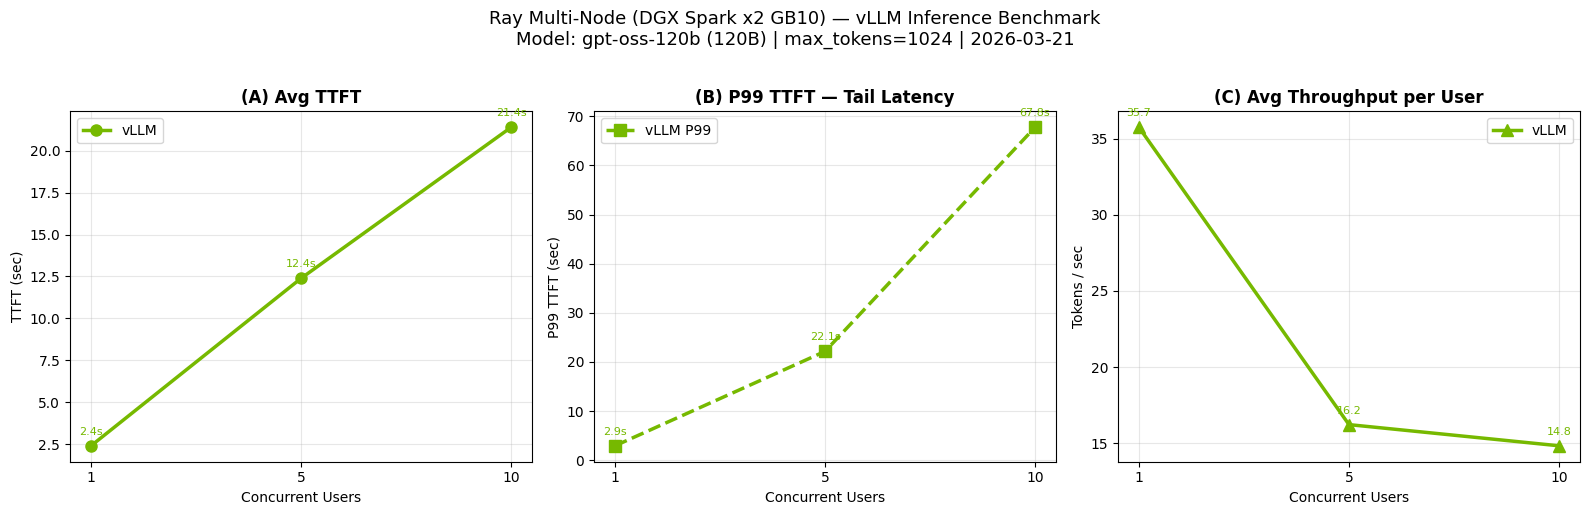

Chart saved → ray_multinode_benchmark.png


In [9]:
import matplotlib.pyplot as plt
from datetime import datetime

CONCURRENCY_LEVELS = [1, 5, 10]
COLOR = "#76b900"  # vLLM green

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Ray Multi-Node (DGX Spark x2 GB10) — vLLM Inference Benchmark\n"
    f"Model: gpt-oss-120b (120B) | max_tokens=1024 | {datetime.now().strftime('%Y-%m-%d')}",
    fontsize=13, y=1.02
)

sub = summary_vllm.sort_values("concurrency")
x_labels = [str(c) for c in sub["concurrency"]]

# ── (A) TTFT Mean ──────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(x_labels, sub["ttft_mean_sec"],
        marker="o", color=COLOR, linewidth=2.5, markersize=8, label="vLLM")
for _, row in sub.iterrows():
    ax.annotate(f"{row.ttft_mean_sec:.1f}s",
                (str(int(row.concurrency)), row.ttft_mean_sec),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=8, color=COLOR)
ax.set_title("(A) Avg TTFT", fontweight="bold", fontsize=12)
ax.set_xlabel("Concurrent Users")
ax.set_ylabel("TTFT (sec)")
ax.legend()
ax.grid(True, alpha=0.3)

# ── (B) P99 TTFT ───────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(x_labels, sub["ttft_p99_sec"],
        marker="s", linestyle="--", color=COLOR, linewidth=2.5, markersize=8, label="vLLM P99")
for _, row in sub.iterrows():
    ax.annotate(f"{row.ttft_p99_sec:.1f}s",
                (str(int(row.concurrency)), row.ttft_p99_sec),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=8, color=COLOR)
ax.set_title("(B) P99 TTFT — Tail Latency", fontweight="bold", fontsize=12)
ax.set_xlabel("Concurrent Users")
ax.set_ylabel("P99 TTFT (sec)")
ax.legend()
ax.grid(True, alpha=0.3)

# ── (C) Per-user TPS ───────────────────────────────────────────────────────
ax = axes[2]
ax.plot(x_labels, sub["tps_mean"],
        marker="^", color=COLOR, linewidth=2.5, markersize=8, label="vLLM")
for _, row in sub.iterrows():
    ax.annotate(f"{row.tps_mean:.1f}",
                (str(int(row.concurrency)), row.tps_mean),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=8, color=COLOR)
ax.set_title("(C) Avg Throughput per User", fontweight="bold", fontsize=12)
ax.set_xlabel("Concurrent Users")
ax.set_ylabel("Tokens / sec")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ray_multinode_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → ray_multinode_benchmark.png")

# Ray benchmark save

In [10]:
from IPython.display import Markdown
from datetime import datetime
import json

# Raw data 저장
df_vllm.to_csv("ray_multinode_raw_results.csv", index=False)

# Summary 저장
summary_vllm.to_csv("ray_multinode_summary.csv", index=False)

# 실험 메타데이터
meta = {
    "date": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "engine": "vLLM",
    "setup": "Ray multi-node (DGX Spark x2)",
    "nodes": [
        {"role": "head",   "host": "spark-0c1a", "ip": "192.168.100.10", "hw": "GB10 128GB"},
        {"role": "worker", "host": "spark-f420",  "ip": "192.168.100.11", "hw": "GB10 128GB"},
    ],
    "model": "gpt-oss-120b",
    "max_new_tokens": MAX_NEW_TOKENS,
    "concurrency_levels": CONCURRENCY_LEVELS,
    "requests_per_user": REQUESTS_PER_USER,
    "timeout": REQUEST_TIMEOUT,
    "vllm_config": {
        "tensor_parallel_size": 2,
        "distributed_executor_backend": "ray",
        "max_num_seqs": 8,
        "max_num_batched_tokens": 16384,
        "max_model_len": 131072,
        "gpu_memory_utilization": 0.85,
        "async_scheduling": True,
        "swap_space": 32,
    }
}
with open("ray_multinode_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

# BENCHMARK_RESULTS.md 생성
rows = ""
for _, r in summary_vllm.iterrows():
    rows += (f"| {int(r.concurrency)} | "
             f"{r.ttft_mean_sec:.2f} | {r.ttft_p50_sec:.2f} | "
             f"{r.ttft_p95_sec:.2f} | {r.ttft_p99_sec:.2f} | "
             f"{r.tps_mean:.1f} |\n")

md = f"""## Ray Multi-Node vLLM — Benchmark Results

**Setup:** Ray cluster across 2× DGX Spark GB10 (128GB unified memory each)  
**Model:** gpt-oss-120b (120B parameters, MXFP4)  
**Engine:** vLLM {" ".join(["0.10.1.1"])} | tensor_parallel_size=2 | distributed_executor_backend=ray  
**Date:** {datetime.now().strftime('%Y-%m-%d')}  
**Note:** req_id=0 (cold-start warm-up) excluded from aggregation.

| Concurrency | TTFT mean (s) | TTFT P50 (s) | TTFT P95 (s) | TTFT P99 (s) | TPS (tok/s) |
|:-----------:|:-------------:|:------------:|:------------:|:------------:|:-----------:|
{rows}
![Chart](ray_multinode_benchmark.png)
"""

with open("RAY_BENCHMARK_RESULTS.md", "w", encoding="utf-8") as f:
    f.write(md)

print("Saved ✓")
print("  ray_multinode_raw_results.csv")
print("  ray_multinode_summary.csv")
print("  ray_multinode_meta.json")
print("  RAY_BENCHMARK_RESULTS.md")
Markdown(md)

Saved ✓
  ray_multinode_raw_results.csv
  ray_multinode_summary.csv
  ray_multinode_meta.json
  RAY_BENCHMARK_RESULTS.md


## Ray Multi-Node vLLM — Benchmark Results

**Setup:** Ray cluster across 2× DGX Spark GB10 (128GB unified memory each)  
**Model:** gpt-oss-120b (120B parameters, MXFP4)  
**Engine:** vLLM 0.10.1.1 | tensor_parallel_size=2 | distributed_executor_backend=ray  
**Date:** 2026-03-21  
**Note:** req_id=0 (cold-start warm-up) excluded from aggregation.

| Concurrency | TTFT mean (s) | TTFT P50 (s) | TTFT P95 (s) | TTFT P99 (s) | TPS (tok/s) |
|:-----------:|:-------------:|:------------:|:------------:|:------------:|:-----------:|
| 1 | 2.41 | 2.41 | 2.88 | 2.92 | 35.7 |
| 5 | 12.39 | 11.91 | 21.44 | 22.14 | 16.2 |
| 10 | 21.39 | 10.26 | 55.73 | 67.75 | 14.8 |

![Chart](ray_multinode_benchmark.png)
